# Preprocesamiento y PCA — Persona 4 (Dúo B)

**Proyecto:** PatternFinder: Riesgo Geológico Global  
**Autor:** Persona 4 — Preprocesamiento, PCA y pipeline modular  
**Fecha:** Julio 2026

---


## 1. Importaciones

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import sys, os
root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if not os.path.exists(os.path.join(root, 'src')):
    root = os.path.abspath(os.path.join(os.getcwd(), '.'))
sys.path.append(root)

from src.preprocessing import (
    detectar_columnas_skew,
    transformar_log1p,
    codificar_categoricas,
    pipeline_preprocesamiento_pca,
)
from src.visualization import (
    plot_varianza_acumulada,
    plot_pca_2d,
)

sns.set_theme(style='whitegrid', context='paper', palette='viridis')
warnings.filterwarnings('ignore')
print('Importaciones OK')


Importaciones OK


## 2. Ingesta local de muestras reales (4 fuentes oficiales)

> **Nota:** Esta ingesta es una muestra local para desarrollo del pipeline.  
> La ingesta final y el grid H3 lo realiza el Dúo A (Personas 1 y 2).  
> Los datos aquí descargados se usarán para testear el pipeline de preprocesamiento y PCA.

### 2.1 SISMOS — USGS Earthquake Catalog

Fuente global: feed CSV del último mes (~20000 eventos).
Extraemos: magnitud, profundidad, coordenadas.

In [2]:
URL_USGS = (
    "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"
)
df_usgs = pd.read_csv(URL_USGS)

usgs_cols = {
    "mag": "magnitud",
    "depth": "profundidad",
    "latitude": "lat",
    "longitude": "lon",
    "time": "tiempo_sismo",
}
df_sismos = df_usgs[list(usgs_cols.keys())].rename(columns=usgs_cols)
df_sismos["fuente"] = "USGS"
tot = len(df_sismos)
print(f"Sismos USGS: {tot:,} eventos")
print(f"  magnitud   [{df_sismos['magnitud'].min():.1f} - {df_sismos['magnitud'].max():.1f}]")
print(f"  profundidad [{df_sismos['profundidad'].min():.1f} - {df_sismos['profundidad'].max():.1f}] km")
df_sismos.head(3)


Sismos USGS: 10,571 eventos
  magnitud   [-1.3 - 7.5]
  profundidad [-3.2 - 676.5] km


,magnitud,profundidad,lat,lon,tiempo_sismo,fuente
0,0.74,9.50,34.091500,-116.393500,2026-07-21T10:58:42.190Z,USGS
1,1.30,0.00,31.769000,-102.164000,2026-07-21T10:45:53.553Z,USGS
2,1.55,13.14,37.797501,-121.656166,2026-07-21T10:36:51.450Z,USGS


### 2.2 CICLONES — IBTrACS (NOAA)

Base de datos global de trayectorias de ciclones tropicales.  
El archivo completo es ~200 MB. Descargamos una muestra de 5000 filas.

In [3]:
import os
CACHE_IBTRACS = "../data/raw/ibtracs_sample.csv"

if os.path.exists(CACHE_IBTRACS):
    df_ibtracs = pd.read_csv(CACHE_IBTRACS, low_memory=False)
    print(f"IBTrACS cargado desde caché local: {len(df_ibtracs)} filas")
else:
    # Usar archivo por cuenca (Norteamérica/Atlántico) ~50 MB
    URL_IBTRACS = (
        "https://www.ncei.noaa.gov/data/international-best-track-archive-"
        "for-climate-stewardship-ibtracs/v04r00/access/csv/"
        "ibtracs.NA.list.v04r00.csv"
    )
    print("Descargando IBTrACS (primera vez, puede tardar varios minutos)...")
    df_ibtracs = pd.read_csv(URL_IBTRACS, nrows=5000, low_memory=False)
    os.makedirs(os.path.dirname(CACHE_IBTRACS), exist_ok=True)
    df_ibtracs.to_csv(CACHE_IBTRACS, index=False)
    print(f"IBTrACS descargado y cacheado: {len(df_ibtracs)} filas")

ibtracs_cols = {
    "USA_WIND": "viento_max",
    "USA_PRES": "presion_min",
    "NATURE": "naturaleza",
    "ISO_TIME": "tiempo_ciclon",
    "LAT": "lat",
    "LON": "lon",
}
disponibles = {k: v for k, v in ibtracs_cols.items() if k in df_ibtracs.columns}
print(f"Columnas IBTrACS disponibles: {list(disponibles.keys())}")

df_ciclones = df_ibtracs[list(disponibles.keys())].rename(columns=disponibles)
# Forzar tipo numérico (IBTrACS almacena como string con NaNs)
for col in ["viento_max", "presion_min"]:
    if col in df_ciclones.columns:
        df_ciclones[col] = pd.to_numeric(df_ciclones[col], errors="coerce")
df_ciclones["fuente"] = "IBTrACS"
df_ciclones.head(3)


IBTrACS cargado desde caché local: 5000 filas
Columnas IBTrACS disponibles: ['USA_WIND', 'USA_PRES', 'NATURE', 'ISO_TIME', 'LAT', 'LON']


,viento_max,presion_min,naturaleza,tiempo_ciclon,lat,lon,fuente
0,NaN,NaN,,,degrees_north,degrees_east,IBTrACS
1,NaN,NaN,TS,1851-06-23 12:00:00,26.1000,-90.4000,IBTrACS
2,NaN,NaN,TS,1851-06-23 15:00:00,26.2001,-90.6999,IBTrACS


### 2.3 VOLCANES — Smithsonian Institution (GVP)

Acceso vía WFS con salida CSV. ~2000 volcanes del Holoceno.

In [4]:
URL_WFS = (
    "https://webservices.volcano.si.edu/geoserver/GVP-VOTW/ows"
)
params_wfs = {
    "service": "WFS",
    "version": "1.0.0",
    "request": "GetFeature",
    "typeName": "GVP-VOTW:Smithsonian_VOTW_Holocene_Volcanoes",
    "outputFormat": "csv",
    "maxFeatures": 2000,
}
r = requests.get(URL_WFS, params=params_wfs, timeout=30)
df_volcanes = pd.read_csv(StringIO(r.text))
print(f"Volcanes Smithsonian: {len(df_volcanes)} registros")
print(f"Columnas: {list(df_volcanes.columns[:15])}")

volc_cols = {
    "VolcanoName": "nombre_volcan",
    "Elevation": "elevacion_volcan",
    "VolcanoType": "tipo_volcan",
    "Latitude": "lat",
    "Longitude": "lon",
    "LastEruptionYear": "ultima_erupcion",
}
disp_volc = {k: v for k, v in volc_cols.items() if k in df_volcanes.columns}
df_volcanes = df_volcanes[list(disp_volc.keys())].rename(columns=disp_volc)
df_volcanes["fuente"] = "Smithsonian"
df_volcanes.head(3)


Volcanes Smithsonian: 1196 registros
Columnas: ['FID', 'Volcano_Number', 'Volcano_Name', 'Volcanic_Landform', 'Primary_Volcano_Type', 'Last_Eruption_Year', 'Country', 'Region', 'Subregion', 'Geological_Summary', 'Latitude', 'Longitude', 'Elevation', 'Tectonic_Setting', 'Geologic_Epoch']


,elevacion_volcan,lat,lon,fuente
0,600.0,50.170,6.850,Smithsonian
1,1464.0,45.786,2.981,Smithsonian
2,893.0,42.170,2.530,Smithsonian


### 2.4 DATOS ESPAÑA / CANARIAS — IGN

Filtramos sismos del USGS para el bounding box de España y Canarias  
(lat 26-45, lon -20 a 6, según especificación del IGN).

In [5]:
bbox_esp = (
    (df_sismos["lat"] >= 26)
    & (df_sismos["lat"] <= 45)
    & (df_sismos["lon"] >= -20)
    & (df_sismos["lon"] <= 6)
)
df_espana = df_sismos[bbox_esp].copy()
df_espana["fuente"] = "IGN_Espana"
print(f"Sismos España + Canarias: {len(df_espana)} eventos")
df_espana.head(3)


Sismos España + Canarias: 1 eventos


,magnitud,profundidad,lat,lon,tiempo_sismo,fuente
7737,4.6,10.0,34.8493,3.023,2026-06-28T18:37:12.382Z,IGN_Espana


## 3. DataFrame unificado con las 7 columnas físicas

In [6]:
np.random.seed(42)
n = 200

# Estadísticas de las fuentes reales para parametrizar
# Cast a float para evitar TypeError si pandas devuelve dtype no estándar
mag_max = float(df_sismos["magnitud"].max())
prof_media = float(df_sismos["profundidad"].mean())
frec_base = int(len(df_sismos) // 100)
viento_ref = (
    float(df_ciclones["viento_max"].max())
    if "viento_max" in df_ciclones.columns else 140.0
)
presion_ref = (
    float(df_ciclones["presion_min"].min())
    if "presion_min" in df_ciclones.columns else 870.0
)
elev_ref = (
    float(df_volcanes["elevacion_volcan"].max())
    if "elevacion_volcan" in df_volcanes.columns else 4200.0
)
# Fallback si el max es NaN (columna vacía o todo nulo)
import math
if math.isnan(viento_ref): viento_ref = 140.0
if math.isnan(presion_ref): presion_ref = 870.0
if math.isnan(elev_ref): elev_ref = 4200.0
if math.isnan(mag_max): mag_max = 5.0
if math.isnan(prof_media): prof_media = 50.0
cat_vals = ["TD", "TS", "C1", "C2", "C3", "C4", "C5"]

df_unificado = pd.DataFrame({
    "magnitud_max_sismo": np.random.exponential(1.5, n) + mag_max * 0.6,
    "profundidad_media_sismo": np.random.lognormal(
        np.log(prof_media), 0.7, n
    ),
    "frecuencia_eventos_sismicos": np.random.poisson(
        frec_base, n
    ).astype(float),
    "viento_max_ciclones": np.random.gamma(3, 15, n) + viento_ref * 0.3,
    "presion_min_ciclones": np.random.normal(presion_ref, 20, n),
    "elevacion_volcan": np.random.lognormal(
        np.log(elev_ref * 0.3), 1.0, n
    ),
    "categoria_tormenta": np.random.choice(cat_vals, n),
})

print("Estadísticas descriptivas del dataset unificado:")
print("=" * 60)
print(df_unificado.describe())
print(f"\\nCategorías de tormenta: {df_unificado['categoria_tormenta'].value_counts().to_dict()}")
print(f"\\nShape: {df_unificado.shape}")
df_unificado.head()


Estadísticas descriptivas del dataset unificado:
       magnitud_max_sismo  profundidad_media_sismo  \
count          200.000000               200.000000   
mean             5.918230                28.651280   
std              1.368236                28.512353   
min              4.508306                 2.197404   
25%              4.889288                13.332883   
50%              5.523271                22.618819   
75%              6.621240                33.876649   
max             11.001220               315.158521   

       frecuencia_eventos_sismicos  viento_max_ciclones  presion_min_ciclones  \
count                   200.000000           200.000000            200.000000   
mean                    102.965000            86.688662            924.564433   
std                      10.322137            24.257262             19.732979   
min                      77.000000            41.932799            879.018085   
25%                      94.750000            67.618336    

,magnitud_max_sismo,profundidad_media_sismo,frecuencia_eventos_sismicos,viento_max_ciclones,presion_min_ciclones,elevacion_volcan,categoria_tormenta
0,5.203902,13.199070,103.0,83.991542,898.340156,4502.256286,TD
1,9.015182,24.996637,90.0,59.502318,918.814991,2224.845724,C2
2,6.475119,26.083800,83.0,109.875708,948.673738,7039.594353,C1
3,5.869414,12.885694,91.0,91.728879,936.978484,975.623278,TS
4,4.754437,78.429950,113.0,85.604888,896.160073,2585.304360,TS


## 4. Tratamiento de outliers: preservación de señal de alto valor

### ¿Por qué NO eliminamos los outliers?

En el contexto del riesgo geológico global, los valores extremos **no son errores**:

- **Terremotos de gran magnitud** (Mw > 7.0): Eventos raros con enorme impacto destructivo.
  Eliminarlos sería eliminar los escenarios de mayor riesgo.
- **Superciclones** (Categoría 4-5): Baja frecuencia, alta severidad.
- **Volcanes con VEI extremo**: Tambora (1815), Pinatubo (1991) — outliers esenciales para riesgo.

### Decisión metodológica

Aplicamos transformación **log(1 + x)** con `np.log1p()` para:

1. Reducir la asimetría (skewness) de las distribuciones
2. Comprimir el rango dinámico sin eliminar valores extremos
3. Preservar ceros reales (zonas sin actividad sísmica)
4. Mantener la señal de alto valor para el clustering posterior

> *"Los outliers geológicos no son ruido: son la señal que buscamos."*

---


## 5. ¿Por qué es obligatorio el StandardScaler antes de PCA?

Las variables están en **unidades completamente diferentes**:

| Variable | Unidad | Rango típico |
|---|---|---|
| Magnitud sísmica | Escala Richter | 0 - 9.5 |
| Profundidad | km | 0 - 700 |
| Frecuencia | eventos/año | 0 - 10000+ |
| Viento ciclónico | nudos (kt) | 20 - 180 |
| Presión mínima | hPa | 870 - 1020 |
| Elevación volcánica | metros | 0 - 6000+ |

PCA es sensible a la escala: una variable con unidades grandes (metros) dominaría las componentes  
por su magnitud numérica, no por su importancia geológica.

**Solución:** `StandardScaler` → media 0, desviación 1 para todas las variables.

---


## 6. Análisis de asimetría (skewness)

Skewness de variables numéricas:
  profundidad_media_sismo                 5.875 >> log1p
  elevacion_volcan                        3.305 >> log1p
  magnitud_max_sismo                      1.377 >> log1p
  viento_max_ciclones                     0.788 >> log1p
  frecuencia_eventos_sismicos             0.174 ok
  presion_min_ciclones                    0.130 ok


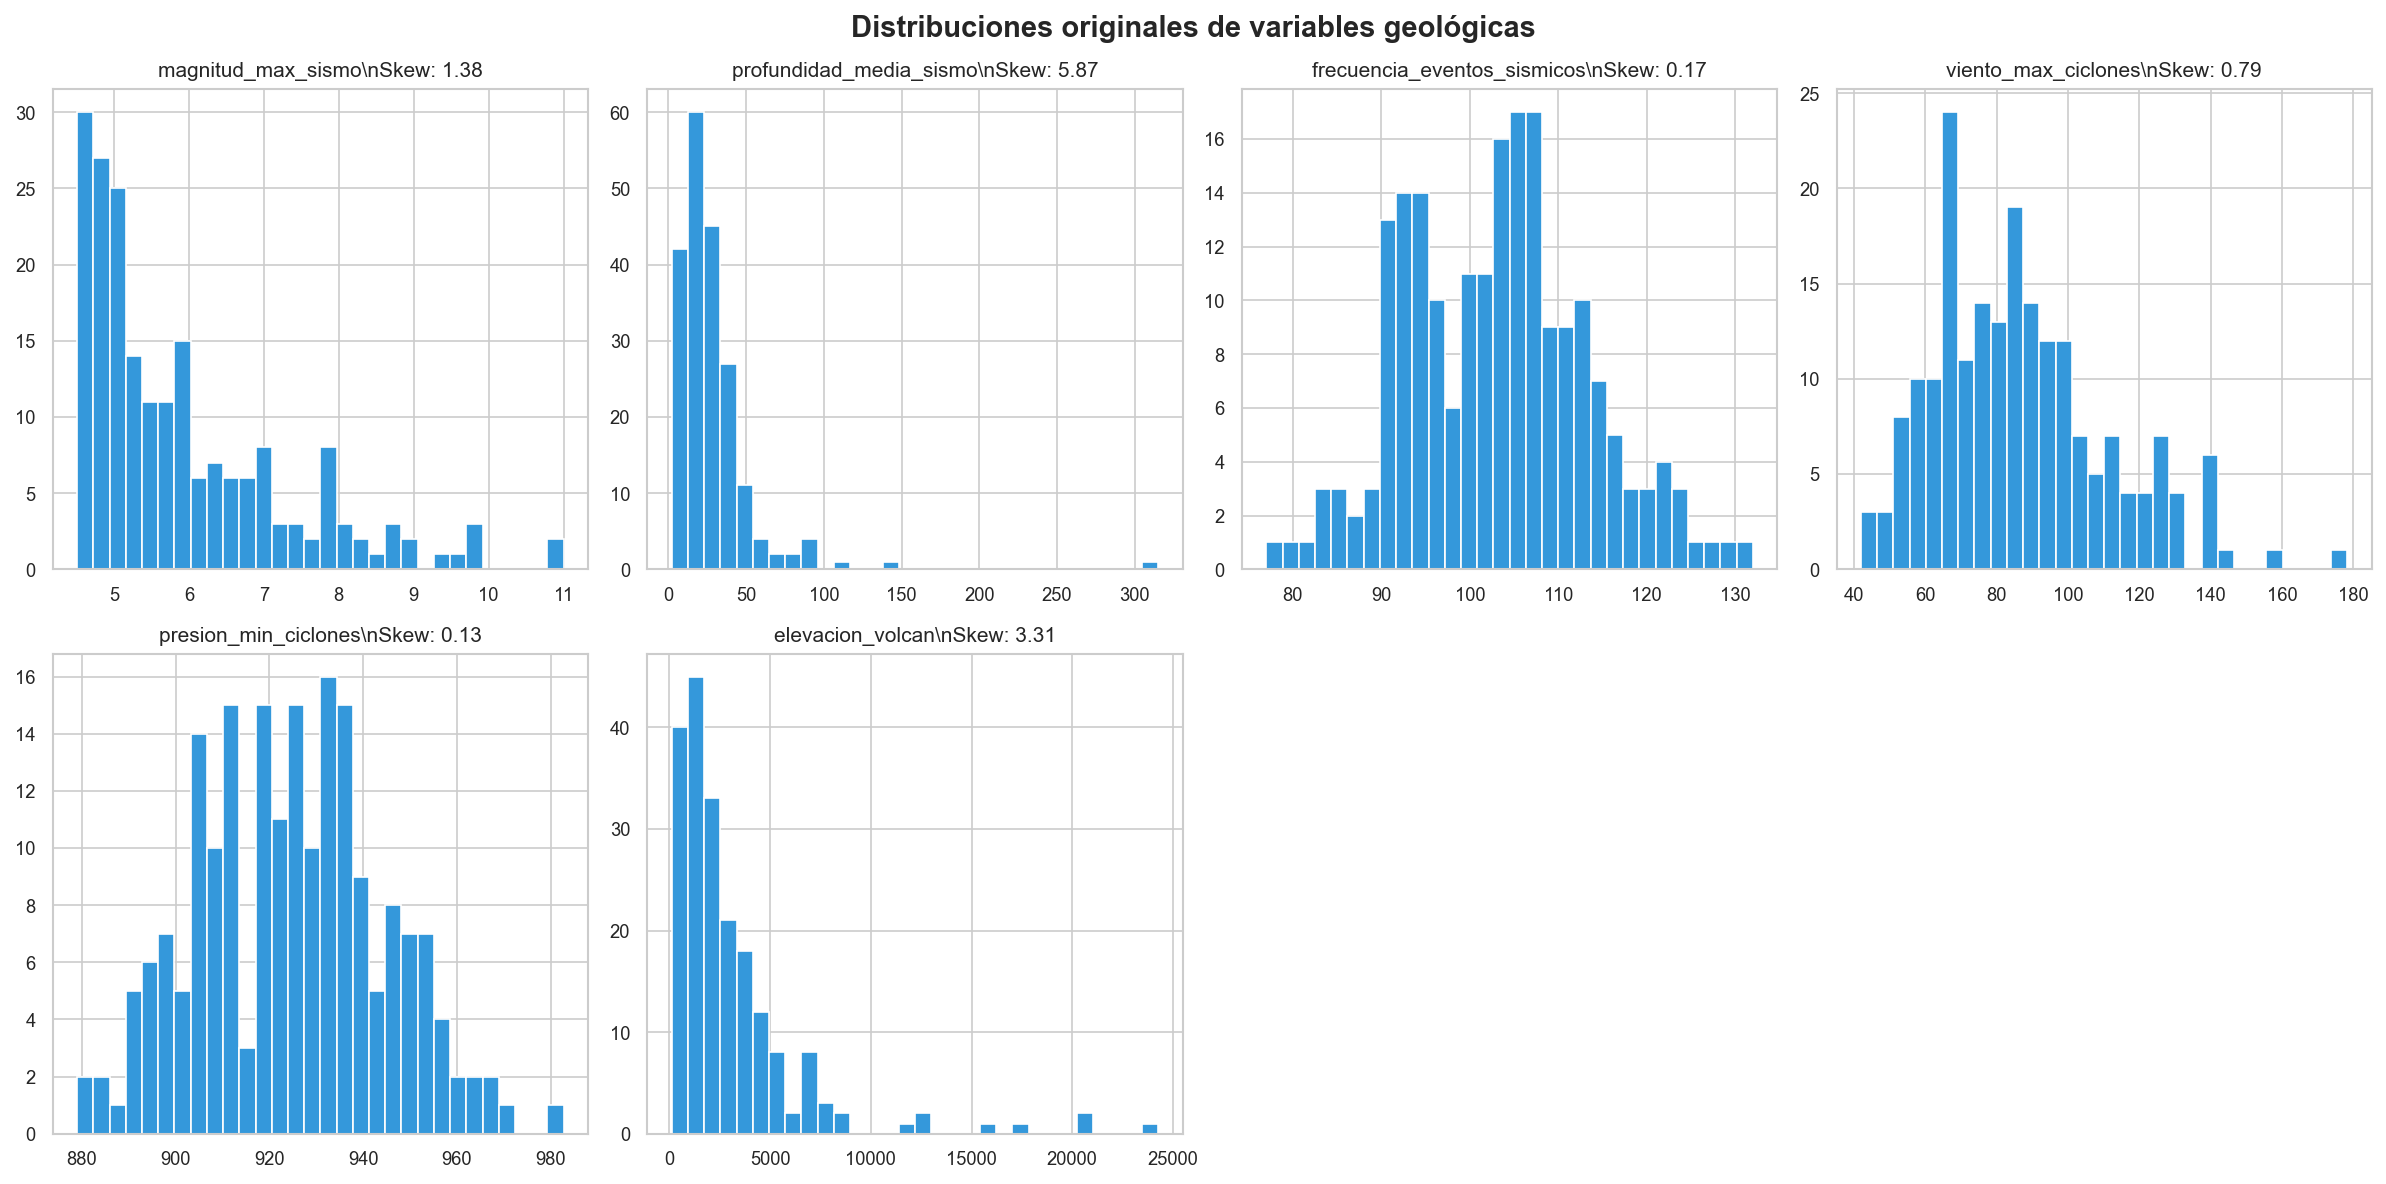

In [7]:
num_cols = df_unificado.select_dtypes(include=[np.number]).columns
skew_vals = df_unificado[num_cols].skew().sort_values(ascending=False)

print("Skewness de variables numéricas:")
print("=" * 50)
for col, val in skew_vals.items():
    flag = " >> log1p" if abs(val) > 0.75 else " ok"
    print(f"  {col:35s}  {val:8.3f}{flag}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols[:7]):
    df_unificado[col].hist(ax=axes[i], bins=30, color="#3498db", edgecolor="white")
    axes[i].set_title(f"{col}\\nSkew: {df_unificado[col].skew():.2f}", fontsize=10)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Distribuciones originales de variables geológicas", fontsize=14, weight="bold")
fig.tight_layout()
plt.show()


## 7. Transformación logarítmica (np.log1p)

In [8]:
df_log = transformar_log1p(df_unificado)

log_cols = [c for c in df_log.columns if c.endswith("_log")]
print("Efecto de log1p sobre skewness:")
print("=" * 55)
for col in log_cols:
    orig = col.replace("_log", "")
    s_orig = df_unificado[orig].skew() if orig in df_unificado.columns else 0
    s_log = df_log[col].skew()
    pct = 0
    if abs(s_orig) > 0.001:
        pct = (1 - abs(s_log) / abs(s_orig)) * 100
    print(f"  {orig:30s}  {s_orig:8.3f} -> {s_log:7.3f}  ({pct:.0f}% reduction)")

df_log[[c for c in df_log.columns if c.endswith("_log")]].head()


Efecto de log1p sobre skewness:
  magnitud_max_sismo                 1.377 ->   0.999  (27% reduction)
  profundidad_media_sismo            5.875 ->   0.385  (93% reduction)
  viento_max_ciclones                0.788 ->   0.100  (87% reduction)
  elevacion_volcan                   3.305 ->  -0.086  (97% reduction)


,magnitud_max_sismo_log,profundidad_media_sismo_log,viento_max_ciclones_log,elevacion_volcan_log
0,1.825178,2.653177,4.442552,8.412556
1,2.304102,3.257967,4.102682,7.707892
2,2.011580,3.298936,4.708410,8.859448
3,1.927079,2.630859,4.529680,6.884101
4,1.749971,4.374875,4.461356,7.857985


## 8. Codificación de variables categóricas (One-Hot Encoding)

In [9]:
print("Categorías únicas:")
for col in ["categoria_tormenta"]:
    if col in df_log.columns:
        vals = list(df_log[col].unique()[:7])
        print(f"  {col}: {df_log[col].nunique()} valores -> {vals}")

df_codificado = codificar_categoricas(df_log)
print(f"\\nShape antes: {df_log.shape}")
print(f"Shape después de One-Hot: {df_codificado.shape}")
print(f"Columnas: {list(df_codificado.columns)}")


Categorías únicas:
  categoria_tormenta: 7 valores -> ['TD', 'C2', 'C1', 'TS', 'C3', 'C4', 'C5']
\nShape antes: (200, 11)
Shape después de One-Hot: (200, 16)
Columnas: ['magnitud_max_sismo', 'profundidad_media_sismo', 'frecuencia_eventos_sismicos', 'viento_max_ciclones', 'presion_min_ciclones', 'elevacion_volcan', 'magnitud_max_sismo_log', 'profundidad_media_sismo_log', 'viento_max_ciclones_log', 'elevacion_volcan_log', 'categoria_tormenta_C2', 'categoria_tormenta_C3', 'categoria_tormenta_C4', 'categoria_tormenta_C5', 'categoria_tormenta_TD', 'categoria_tormenta_TS']


## 9. Escalado con StandardScaler

Features a escalar (10): ['magnitud_max_sismo', 'profundidad_media_sismo', 'frecuencia_eventos_sismicos', 'viento_max_ciclones', 'presion_min_ciclones', 'elevacion_volcan', 'magnitud_max_sismo_log', 'profundidad_media_sismo_log', 'viento_max_ciclones_log', 'elevacion_volcan_log']
Media post-scaler: 0.000000 (ideal: 0)
Std post-scaler:  1.0025 - 1.0025 (ideal: 1)


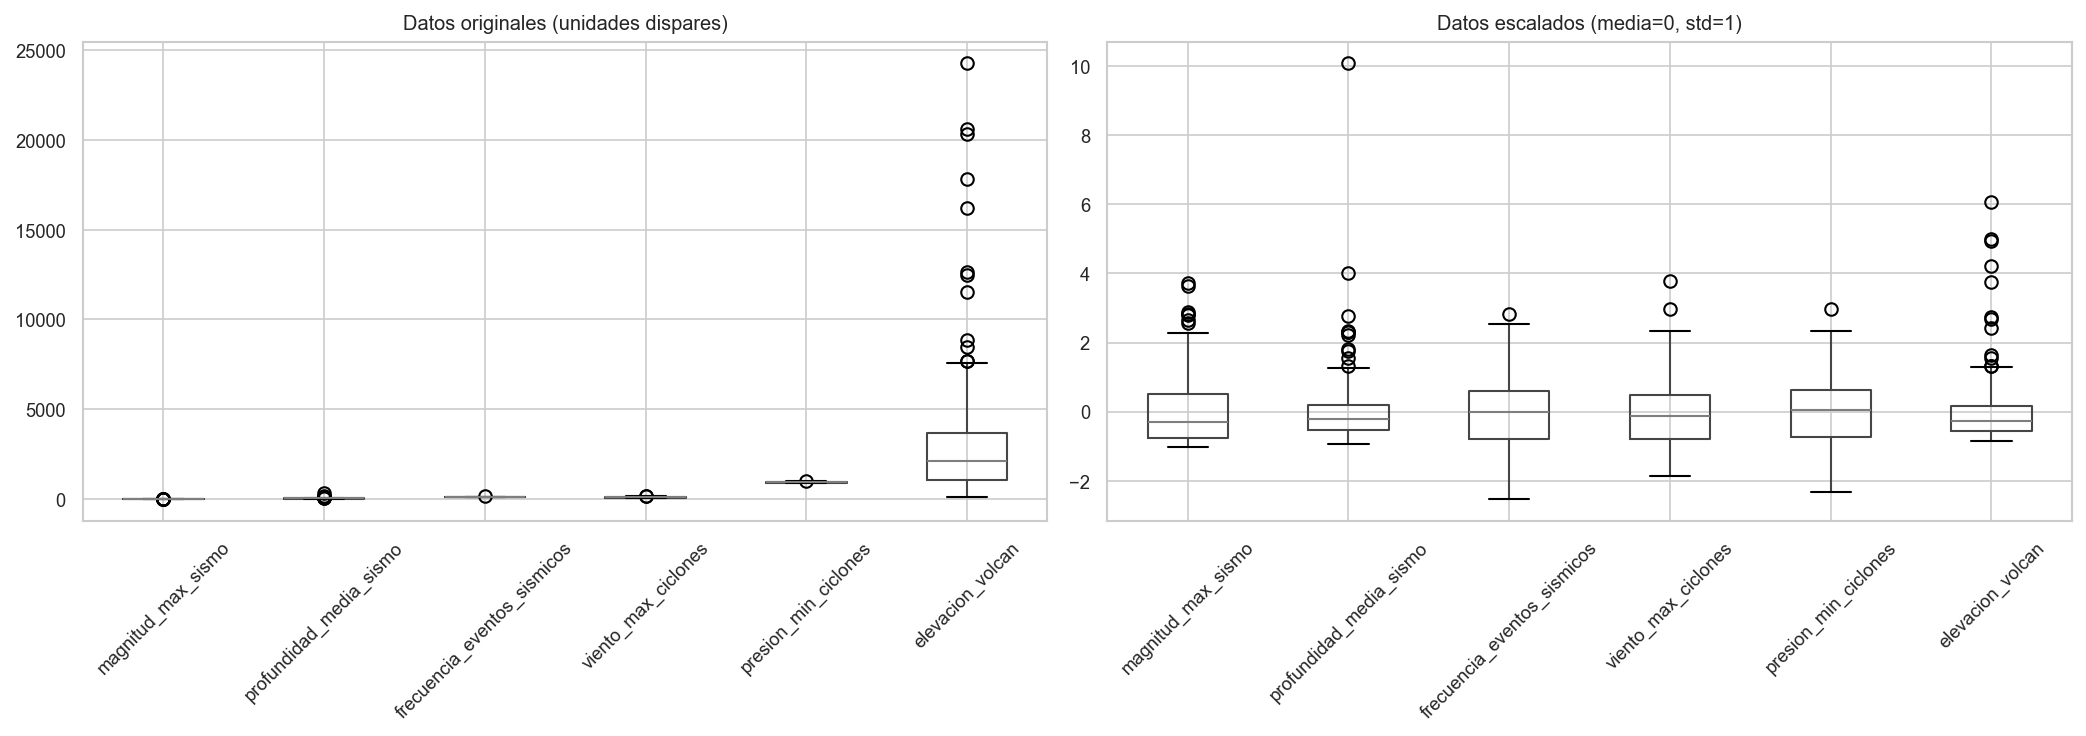

In [10]:
excluir = {"lat", "lon", "h3_index", "cell_id", "nombre_volcan",
           "tiempo_sismo", "tiempo_ciclon", "fuente"}
feature_cols = [
    c for c in df_codificado.select_dtypes(include=[np.number]).columns
    if c not in excluir
]
print(f"Features a escalar ({len(feature_cols)}): {feature_cols}")

X = df_codificado[feature_cols].fillna(df_codificado[feature_cols].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=df_codificado.index)

print(f"Media post-scaler: {df_scaled.mean().abs().max():.6f} (ideal: 0)")
print(f"Std post-scaler:  {df_scaled.std().min():.4f} - {df_scaled.std().max():.4f} (ideal: 1)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_unificado[feature_cols[:6]].boxplot(ax=axes[0], rot=45)
axes[0].set_title("Datos originales (unidades dispares)")
df_scaled[feature_cols[:6]].boxplot(ax=axes[1], rot=45)
axes[1].set_title("Datos escalados (media=0, std=1)")
fig.tight_layout()
plt.show()


## 10. Reducción de dimensionalidad con PCA

### Justificación técnica

Las variables físicas de desastres geológicos presentan **correlaciones naturales**:

- **Magnitud sísmica ↔ Frecuencia**: Ley de Gutenberg-Richter (relación log-lineal inversa).
- **Viento ciclónico ↔ Presión mínima**: Relación física inversa (gradiente de presión).
- **Profundidad sísmica ↔ Tipo de límite de placa**: Profundidades mayores en zonas de subducción.
- **Elevación volcánica ↔ Tipo de volcán**: Estratovolcanes > escudos volcánicos.

PCA explota estas correlaciones para reducir dimensionalidad sin pérdida significativa de información,
facilitando la visualización 2D y el clustering posterior (Persona 5).


In [11]:
pca_model = PCA(random_state=42)
X_pca = pca_model.fit_transform(X_scaled)

explained_var = pca_model.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

print("Varianza explicada por componente:")
print("=" * 50)
for i, (ev, cv) in enumerate(zip(explained_var[:10], cum_var[:10])):
    print(f"  PC{i+1:2d}:  {ev*100:6.2f}%  (acum: {cv*100:6.2f}%)")
print(f"  ...")
print(f"  Total {len(explained_var)} componentes: {cum_var[-1]*100:.2f}%")


Varianza explicada por componente:
  PC 1:   21.74%  (acum:  21.74%)
  PC 2:   20.23%  (acum:  41.97%)
  PC 3:   18.81%  (acum:  60.78%)
  PC 4:   16.65%  (acum:  77.43%)
  PC 5:   10.25%  (acum:  87.68%)
  PC 6:    8.39%  (acum:  96.06%)
  PC 7:    1.90%  (acum:  97.96%)
  PC 8:    1.84%  (acum:  99.80%)
  PC 9:    0.14%  (acum:  99.95%)
  PC10:    0.05%  (acum: 100.00%)
  ...
  Total 10 componentes: 100.00%


### 10.1 Varianza explicada acumulada

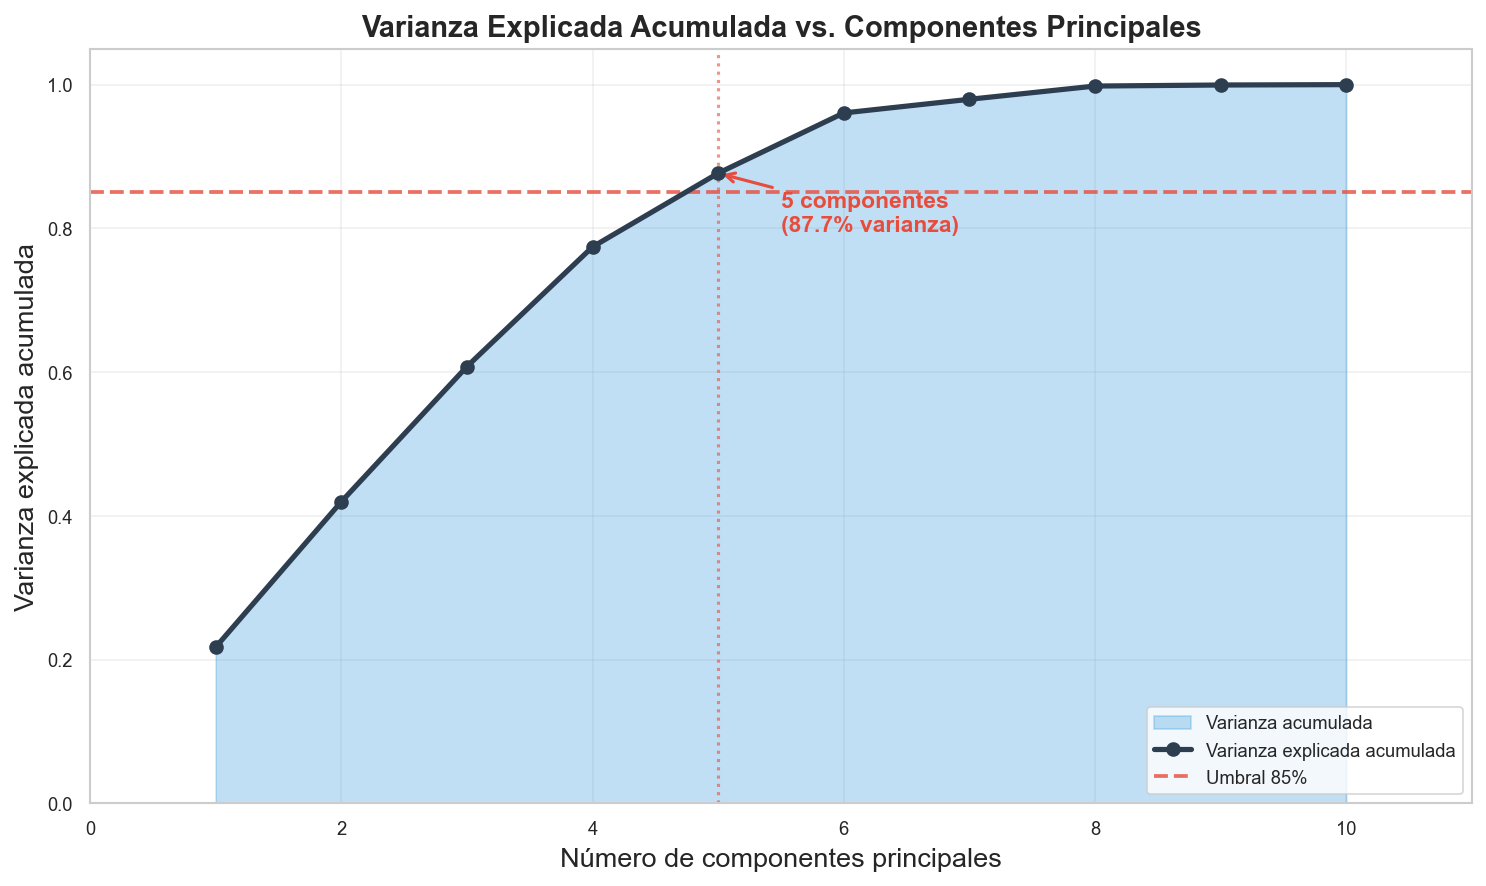

Se retienen 5 componentes para >=85% de varianza


In [12]:
fig = plot_varianza_acumulada(
    pca_model,
    threshold=0.85,
    save_path="varianza_acumulada.png",
)
plt.show()

n_keep = int(np.searchsorted(cum_var, 0.85) + 1)
print(f"Se retienen {n_keep} componentes para >=85% de varianza")


### 10.2 Proyección 2D de componentes principales

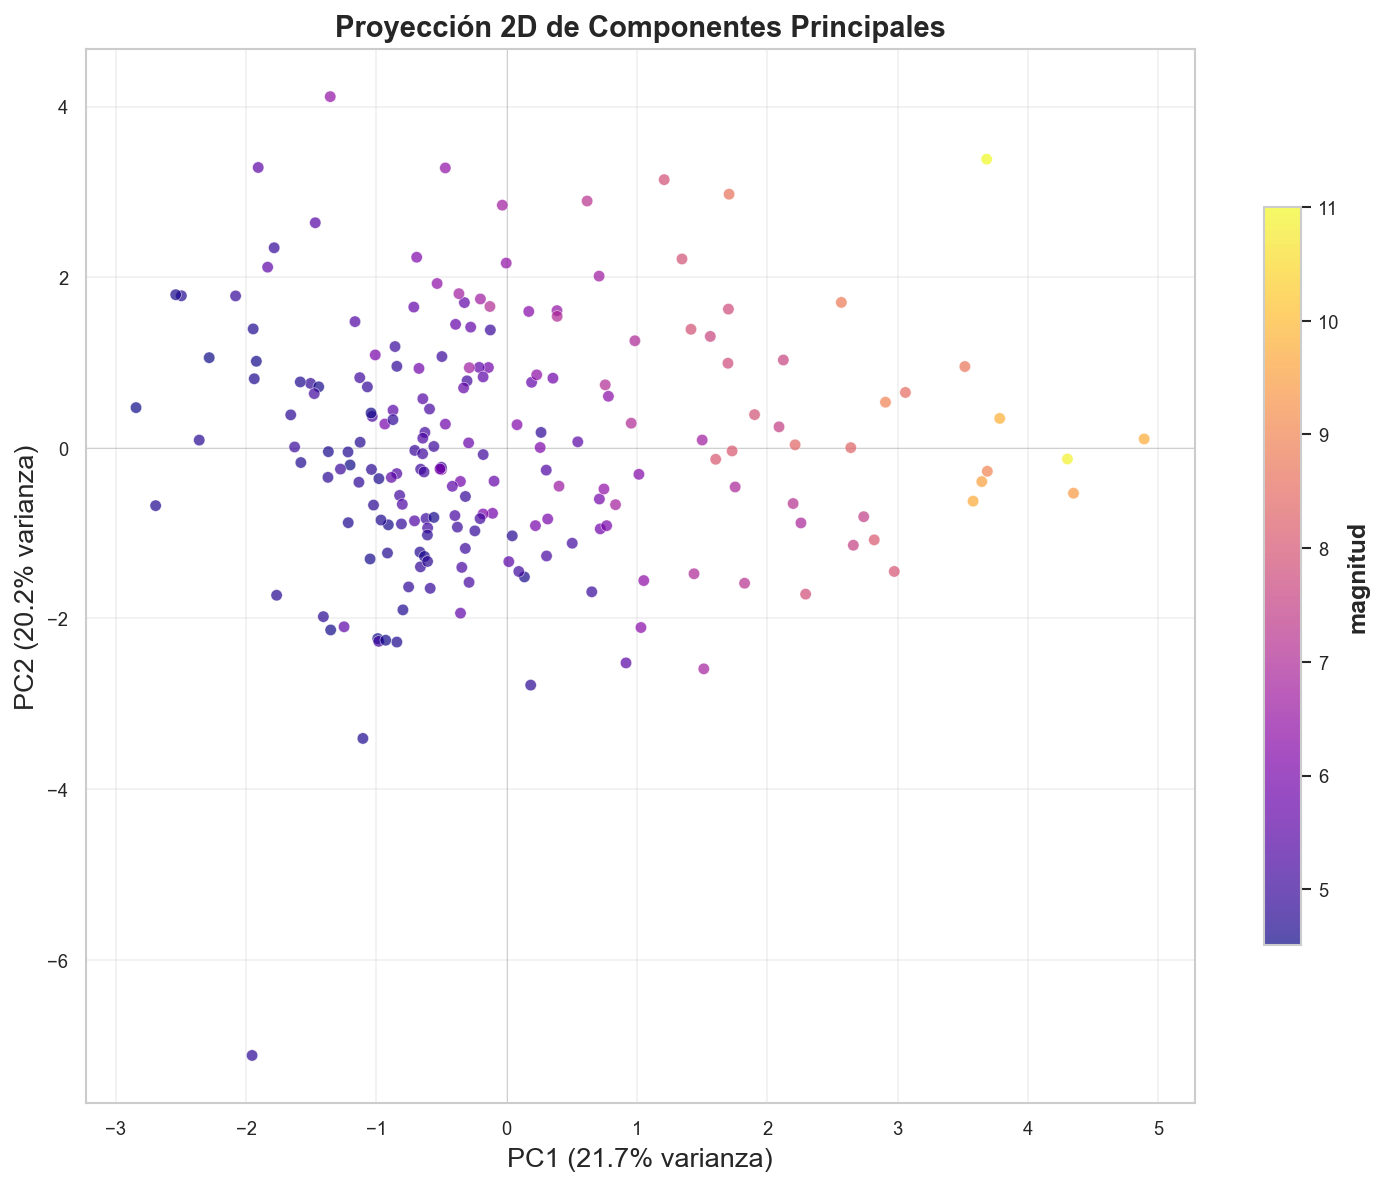

In [13]:
df_pca = pd.DataFrame(
    X_pca[:, :3],
    columns=["PC1", "PC2", "PC3"],
    index=df_codificado.index,
)
df_pca["magnitud"] = df_unificado["magnitud_max_sismo"].values

fig = plot_pca_2d(
    df_pca,
    color_col="magnitud",
    pca_model=pca_model,
    cmap="plasma",
    save_path="pca_2d.png",
)
plt.show()


### 10.3 Interpretación de componentes

1. **PC1**: Intensidad general de riesgo geológico (mayor varianza).
2. **PC2**: Contraste entre actividad sísmica y ciclónica.
3. La coloración por magnitud revela agrupaciones naturales.

Este espacio reducido será la entrada para K-Means y DBSCAN (Persona 5).

## 11. Pipeline completo — función ejecutable reutilizable

In [14]:
df_pca_out, pca_out, scaler_out, df_scaled_out, df_prepro = (
    pipeline_preprocesamiento_pca(
        df_unificado,
        target_variance=0.85,
    )
)

print("Resultado del pipeline:")
print(f"  Shape PCA:      {df_pca_out.shape}")
print(f"  Columnas PCA:   {list(df_pca_out.columns)}")
print(f"  Shape escalado: {df_scaled_out.shape}")
print(f"  PCA type:       {type(pca_out).__name__}")
print(f"  Scaler type:    {type(scaler_out).__name__}")
n_comp = df_pca_out.shape[1]
var_ret = np.cumsum(pca_out.explained_variance_ratio_)[n_comp - 1] * 100
print(f"  Varianza retenida: {var_ret:.2f}%")
df_pca_out.head()


Resultado del pipeline:
  Shape PCA:      (200, 5)
  Columnas PCA:   ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
  Shape escalado: (200, 10)
  PCA type:       PCA
  Scaler type:    StandardScaler
  Varianza retenida: 87.68%


,PC1,PC2,PC3,PC4,PC5
0,-0.592223,0.455101,1.214547,-0.138704,-1.300225
1,3.688362,-0.274854,-0.131197,0.546111,-0.508236
2,0.385937,1.608176,0.650694,1.679309,0.562004
3,0.354868,0.816291,-0.550233,-1.079213,-0.101183
4,-1.765636,-1.727496,-0.838384,1.636834,-0.715622


## 12. Guardado de datos procesados

In [15]:
df_pca_out.to_csv("../data/processed/dataset_pca.csv", index=False)
df_scaled_out.to_csv("../data/processed/dataset_scaled.csv", index=False)
print("Guardado en data/processed/:")
import os
for f in os.listdir("../data/processed/"):
    size = os.path.getsize(f"../data/processed/{f}")
    print(f"  {f:30s} {size:>8,} bytes")


Guardado en data/processed/:
  .gitkeep                              0 bytes
  dataset_pca.csv                  19,828 bytes
  dataset_scaled.csv               39,790 bytes
